# Exercise 7

## Exercise 7a — Estimation of the Angle of the Billiard Cue

The goal of this part is to estimate the angle of the billiard cue in `image31.jpg` with respect to the horizontal axis and then verify the estimation by rotating the image so that the cue becomes approximately horizontal.

The main observation is that the billiard cue is the only object in the image with long, straight edges. Therefore, a suitable approach is to detect edges in the image and then use the Hough Transform to detect long straight line segments.

First, the input image is converted to grayscale, because edge detection and line detection are intensity-based operations. Then, Gaussian smoothing is applied in order to reduce small texture variations and noise before edge detection.

The grayscale image is smoothed using a Gaussian filter:

$$
G(x,y)=\frac{1}{2\pi\sigma^2}
\exp\left(
-\frac{x^2+y^2}{2\sigma^2}
\right)
$$

After smoothing, the Canny edge detector is applied. This produces a binary edge map containing the strong intensity transitions of the image. Since the cue has clear straight boundaries, its edges are expected to appear clearly in the edge map.

Then, the Probabilistic Hough Transform is applied to the edge image in order to detect straight line segments. Each detected line segment is represented by two endpoints:

$$
(x_1,y_1)
\quad \text{and} \quad
(x_2,y_2)
$$

For each detected line segment, its length is computed as:

$$
L=\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}
$$

and its angle with respect to the horizontal axis is computed using:

$$
\theta = \operatorname{atan2}(y_2-y_1,x_2-x_1)
$$

In degrees:

$$
\theta_{\text{deg}} =
\frac{180}{\pi}
\operatorname{atan2}(y_2-y_1,x_2-x_1)
$$

Because the exercise states that the billiard cue is the only object with straight edges, the longest diagonal Hough line segment is selected as the best estimate of the cue direction. Very short line segments are rejected, because they are likely to correspond to small reflections, object boundaries, or noise.

The detected cue line gives the following signed angle in image coordinates:

$$
\theta \approx -51.07^\circ
$$

The negative sign is due to the image coordinate system, where the \(x\)-axis points to the right and the \(y\)-axis points downward. Therefore, a line that rises toward the right has a negative slope and hence a negative signed angle.

However, the angle of the billiard cue with respect to the horizontal axis is usually reported as the absolute value:

$$
|\theta| \approx 51.07^\circ
$$

Therefore, the billiard cue forms an angle of approximately:

$$
51.07^\circ
$$

with the horizontal axis.

To verify this result, the original image is rotated so that the cue becomes horizontal. The rotation is performed using an affine transformation. The rotation matrix around the image center \((c_x,c_y)\) is:

$$
M =
\begin{bmatrix}
\alpha & \beta & (1-\alpha)c_x-\beta c_y \\
-\beta & \alpha & \beta c_x+(1-\alpha)c_y
\end{bmatrix}
$$

where:

$$
\alpha = s\cos\theta
$$

and:

$$
\beta = s\sin\theta
$$

with scale:

$$
s=1
$$

Since the detected signed angle of the cue is:

$$
\theta \approx -51.07^\circ
$$

the image is rotated by this angle using OpenCV's affine rotation convention. This cancels the inclination of the cue and makes it approximately horizontal.

The rotated result confirms the correctness of the estimated angle, because the billiard cue becomes almost horizontal and the resulting image is visually similar to `image32.jpg`.

Therefore, the estimated angle of the billiard cue in `image31.jpg` is:

$$
\boxed{|\theta| \approx 51.07^\circ}
$$

or, including the signed direction in image coordinates:

$$
\boxed{\theta \approx -51.07^\circ}
$$




In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path(r"C:\Users\Konstantinos Krit\Desktop\MSc\Β' Εξάμηνο\Image Analysis & Processing\1st Project")

IMAGE31_PATH = BASE_DIR / "image31.png"
IMAGE32_PATH = BASE_DIR / "image32.png"

def load_color(path):
    image_bytes = np.fromfile(str(path), dtype=np.uint8)
    bgr = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)

    if bgr is None:
        raise ValueError(f"Could not load image: {path}")

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)

    return bgr, rgb, gray


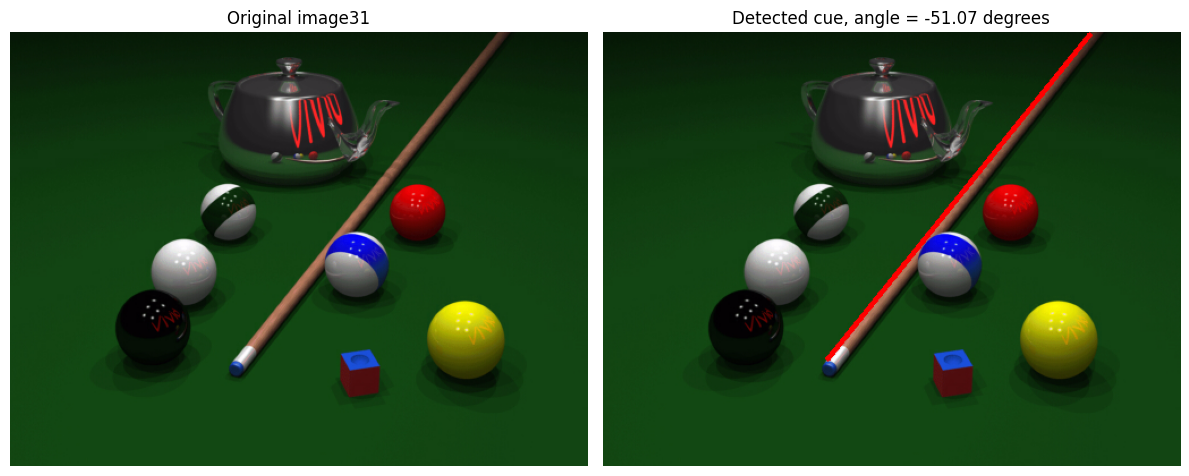

Estimated cue angle relative to horizontal axis: -51.07 degrees
Absolute angle: 51.07 degrees


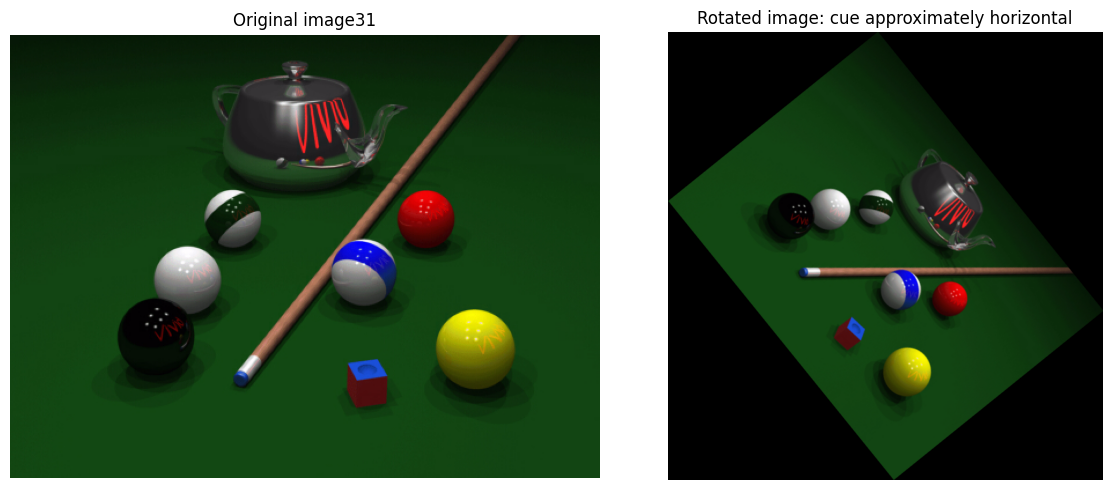

Rotated image saved to:
C:\Users\Konstantinos Krit\Desktop\MSc\Β' Εξάμηνο\Image Analysis & Processing\1st Project\image32_estimated_from_image31.jpg


In [4]:
# ---------------------------------------------------------
# Exercise 7a
# Detect the billiard cue, estimate its angle,
# and rotate image31 so that the cue becomes horizontal.
# ---------------------------------------------------------

bgr31, rgb31, gray31 = load_color(IMAGE31_PATH)

# 1. Smooth image and detect edges
blur = cv2.GaussianBlur(gray31, (5, 5), 1.2)

edges = cv2.Canny(
    blur,
    threshold1=50,
    threshold2=150,
    apertureSize=3,
    L2gradient=True
)

# 2. Detect line segments using Probabilistic Hough Transform
lines = cv2.HoughLinesP(
    edges,
    rho=1,
    theta=np.pi / 180,
    threshold=60,
    minLineLength=120,
    maxLineGap=20
)

if lines is None:
    raise ValueError("No lines detected. Try lowering Hough threshold or minLineLength.")

line_image = rgb31.copy()
candidate_lines = []

h, w = gray31.shape

for line in lines:
    x1, y1, x2, y2 = line[0]

    dx = x2 - x1
    dy = y2 - y1

    length = np.sqrt(dx**2 + dy**2)

    if length < 120:
        continue

    angle = np.degrees(np.arctan2(dy, dx))

    # Normalize angle to [-90, 90]
    if angle > 90:
        angle -= 180
    elif angle < -90:
        angle += 180

    abs_angle = abs(angle)

    # The cue is expected to be the dominant long diagonal line.
    if 25 <= abs_angle <= 80:
        candidate_lines.append((x1, y1, x2, y2, length, angle))

if len(candidate_lines) == 0:
    raise ValueError("No cue-like diagonal lines found.")

# Use the longest detected diagonal line as the cue estimate
cue_line = max(candidate_lines, key=lambda item: item[4])
x1, y1, x2, y2, cue_length, cue_angle = cue_line

cv2.line(line_image, (x1, y1), (x2, y2), (255, 0, 0), 4)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb31)
plt.title("Original image31")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(line_image)
plt.title(f"Detected cue, angle = {cue_angle:.2f} degrees")
plt.axis("off")

plt.tight_layout()
plt.show()

print(f"Estimated cue angle relative to horizontal axis: {cue_angle:.2f} degrees")
print(f"Absolute angle: {abs(cue_angle):.2f} degrees")

# ---------------------------------------------------------
# 3. Rotate image so that the cue becomes horizontal
# In OpenCV image coordinates, rotating by cue_angle
# cancels the detected line inclination.
# ---------------------------------------------------------
center = (w / 2, h / 2)

rotation_matrix = cv2.getRotationMatrix2D(center, cue_angle, 1.0)

# Compute output bounds so the rotated image is not cropped
cos = abs(rotation_matrix[0, 0])
sin = abs(rotation_matrix[0, 1])

new_w = int(h * sin + w * cos)
new_h = int(h * cos + w * sin)

rotation_matrix[0, 2] += new_w / 2 - center[0]
rotation_matrix[1, 2] += new_h / 2 - center[1]

rotated_bgr = cv2.warpAffine(
    bgr31,
    rotation_matrix,
    (new_w, new_h),
    flags=cv2.INTER_LINEAR,
    borderMode=cv2.BORDER_CONSTANT,
    borderValue=(0, 0, 0)
)

rotated_rgb = cv2.cvtColor(rotated_bgr, cv2.COLOR_BGR2RGB)
rotated_gray = cv2.cvtColor(rotated_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(rgb31)
plt.title("Original image31")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(rotated_rgb)
plt.title("Rotated image: cue approximately horizontal")
plt.axis("off")

plt.tight_layout()
plt.show()

# Save result
OUTPUT32_EST = BASE_DIR / "image32_estimated_from_image31.jpg"
success, encoded = cv2.imencode(".jpg", rotated_bgr)

if success:
    encoded.tofile(str(OUTPUT32_EST))
    print(f"Rotated image saved to:\n{OUTPUT32_EST}")


## Exercise 7b — Isolation of the Billiard Cue

The goal of this part is to combine the information from `image31.jpg` and `image32.jpg` in order to generate an image similar to `image33.jpg`, where only the billiard cue remains visible and the rest of the image is suppressed.

From Exercise 7a, the billiard cue angle in `image31.jpg` was estimated and the image was rotated so that the cue became approximately horizontal. Therefore, in `image32.jpg`, the cue appears as a long, thin, almost horizontal structure.

The key observation is that, after rotation, the billiard cue is the only object that matches the pattern of a very long horizontal line. This allows the cue to be detected using edge detection and the Hough Transform.

First, the rotated image is converted to grayscale. Then, Gaussian smoothing is applied in order to reduce small intensity variations before edge detection. The Canny edge detector is then used to extract strong intensity transitions.

The Canny edge detector produces a binary edge image where object boundaries are represented as edge pixels. Since the billiard cue has long straight boundaries, it produces long horizontal edge segments in the rotated image.

Then, the Probabilistic Hough Transform is applied to the edge image. Each detected line segment is represented by two endpoints:

$$
(x_1,y_1)
\quad \text{and} \quad
(x_2,y_2)
$$

For each line segment, its length is computed as:

$$
L=\sqrt{(x_2-x_1)^2+(y_2-y_1)^2}
$$

and its angle with respect to the horizontal axis is computed as:

$$
\theta =
\operatorname{atan2}(y_2-y_1,x_2-x_1)
$$

In degrees:

$$
\theta_{\text{deg}} =
\frac{180}{\pi}
\operatorname{atan2}(y_2-y_1,x_2-x_1)
$$

Since the cue is expected to be horizontal in `image32.jpg`, only line segments with very small angle are accepted:

$$
|\theta| \leq 3^\circ
$$

Short line segments are rejected because they are more likely to correspond to reflections, balls, or other small object boundaries. Therefore, a minimum line length is imposed:

$$
L \geq 100
$$

Additionally, false horizontal lines located in the upper part of the image are rejected. This is useful because some balls and reflective objects may also produce short horizontal edges. Since the true cue is located in the lower part of the rotated image, the midpoint of each candidate line is computed:

$$
y_{\text{mid}} = \frac{y_1+y_2}{2}
$$

and only lines satisfying:

$$
y_{\text{mid}} > 0.45H
$$

are retained, where \(H\) is the image height.

After filtering the Hough lines, the vertical position of the cue is estimated using the median of the accepted line coordinates:

$$
y_{\text{cue}} = \operatorname{median}(y_i)
$$

A narrow horizontal band is then defined around this estimated position:

$$
[y_{\text{cue}}-10,\; y_{\text{cue}}+10]
$$

This restriction is important because the exercise notes that the cue may be connected to a ball in a binary representation of the image. By working only inside a narrow horizontal band around the cue, compact objects such as balls are largely excluded from the analysis.

Inside this cue band, a binary mask is created by thresholding the grayscale intensities:

$$
B(x,y)=
\begin{cases}
255, & I(x,y)>T \\
0, & I(x,y)\leq T
\end{cases}
$$

where \(T=50\) in this implementation.

This produces an initial binary representation of bright structures inside the cue band. However, the binary mask may still contain small unwanted fragments or small gaps along the cue. Therefore, morphological processing is applied.

First, morphological opening is used:

$$
A \circ B = (A \ominus B) \oplus B
$$

where \(A\) is the binary mask and \(B\) is a horizontal structuring element.

Opening consists of erosion followed by dilation. Because a long horizontal structuring element is used, this operation preserves long horizontal structures such as the cue while removing smaller compact objects and noise.

Then, morphological closing is applied:

$$
A \bullet B = (A \oplus B) \ominus B
$$

Closing consists of dilation followed by erosion. It is used to reconnect small gaps along the cue and make the extracted cue mask more continuous.

Finally, connected component analysis is performed on the resulting binary mask. Each connected component is described by its bounding box:

$$
(x,y,w,h)
$$

where \(w\) is the component width and \(h\) is the component height.

The billiard cue is selected as the component that best satisfies the expected geometry of the object:

$$
\text{long}, \quad \text{thin}, \quad \text{horizontal}
$$

This means that the selected component should have a large width and a small height. Equivalently, it should have a large aspect ratio:

$$
\text{aspect ratio} =
\frac{w}{h}
$$

In the implementation, components are accepted only if:

$$
w > 150
$$

and:

$$
h \leq 25
$$

Among these candidate components, the best one is selected using a score that favors long and thin components:

$$
\text{score} =
\frac{w \cdot A}{h+1}
$$

where \(A\) is the area of the connected component. The term \(h+1\) avoids division by zero and penalizes components that are too thick.

After the final cue mask is obtained, it is applied to the grayscale rotated image using a pixelwise mask operation:

$$
I_{\text{cue}}(x,y)=
\begin{cases}
I(x,y), & M(x,y)=255 \\
0, & M(x,y)=0
\end{cases}
$$

where \(M(x,y)\) is the final binary cue mask.

The resulting image contains the isolated billiard cue on a black background. This output is visually similar to `image33.jpg`.

Therefore, the method successfully combines the rotation result from Exercise 7a with line detection, local cue-band analysis, morphological filtering, and connected component selection in order to isolate the billiard cue.

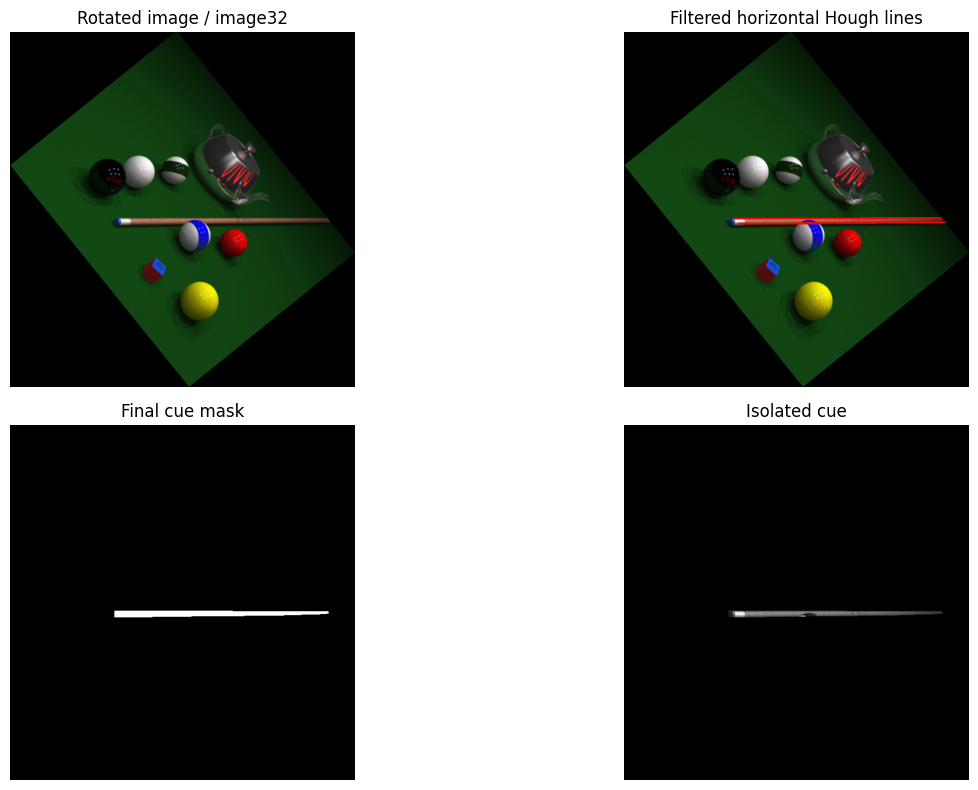

Final cue bounding box:
x = 187-570
y = 334-345
Estimated cue y-position: 342
Number of accepted horizontal Hough lines: 5


In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = Path(r"C:\Users\Konstantinos Krit\Desktop\MSc\Β' Εξάμηνο\Image Analysis & Processing\1st Project")
IMAGE32_PATH = BASE_DIR / "image32.png"

# Use rotated image from 7a if available, otherwise use image32.png
if "rotated_gray" in globals() and "rotated_rgb" in globals():
    gray32 = rotated_gray.copy()
    rgb32 = rotated_rgb.copy()
else:
    image_bytes = np.fromfile(str(IMAGE32_PATH), dtype=np.uint8)
    bgr32 = cv2.imdecode(image_bytes, cv2.IMREAD_COLOR)
    rgb32 = cv2.cvtColor(bgr32, cv2.COLOR_BGR2RGB)
    gray32 = cv2.cvtColor(bgr32, cv2.COLOR_BGR2GRAY)

h, w = gray32.shape

# 1. Canny edges
blur32 = cv2.GaussianBlur(gray32, (5, 5), 1.0)
edges32 = cv2.Canny(blur32, 40, 120, apertureSize=3, L2gradient=True)

# 2. Hough lines
lines32 = cv2.HoughLinesP(
    edges32,
    rho=1,
    theta=np.pi / 180,
    threshold=40,
    minLineLength=100,
    maxLineGap=50
)

if lines32 is None:
    raise ValueError("No lines detected.")

# 3. Keep only long, almost-horizontal lines in lower half
horizontal_lines = []

for line in lines32:
    x1, y1, x2, y2 = line[0]
    dx = x2 - x1
    dy = y2 - y1

    if dx == 0:
        continue

    length = np.sqrt(dx**2 + dy**2)
    angle = np.degrees(np.arctan2(dy, dx))

    if angle > 90:
        angle -= 180
    elif angle < -90:
        angle += 180

    mid_y = (y1 + y2) / 2

    # Reject false horizontal lines from balls / objects above the cue
    if abs(angle) <= 3 and length >= 100 and mid_y > 0.45 * h:
        horizontal_lines.append((x1, y1, x2, y2, length, angle))

if len(horizontal_lines) == 0:
    raise ValueError("No valid cue-like horizontal lines found.")

# 4. Estimate cue band
ys = []
xs = []

for x1, y1, x2, y2, length, angle in horizontal_lines:
    ys.extend([y1, y2])
    xs.extend([x1, x2])

cue_y = int(np.median(ys))
x_min = max(int(min(xs)) - 10, 0)
x_max = min(int(max(xs)) + 10, w - 1)

band_half_height = 10
y_min = max(cue_y - band_half_height, 0)
y_max = min(cue_y + band_half_height + 1, h)

# 5. Build mask only inside cue band
band_roi = gray32[y_min:y_max, x_min:x_max]

# The cue is bright inside this narrow band
cue_roi_mask = (band_roi > 50).astype(np.uint8) * 255

# 6. Morphological processing
# Horizontal opening removes small ball/object residues.
open_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (50, 3))
cue_roi_mask = cv2.morphologyEx(cue_roi_mask, cv2.MORPH_OPEN, open_kernel)

# Closing connects small gaps along the cue.
close_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 3))
cue_roi_mask = cv2.morphologyEx(cue_roi_mask, cv2.MORPH_CLOSE, close_kernel)

cue_mask = np.zeros_like(gray32, dtype=np.uint8)
cue_mask[y_min:y_max, x_min:x_max] = cue_roi_mask

# 7. Keep the largest long horizontal component
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(cue_mask, connectivity=8)

if num_labels <= 1:
    raise ValueError("No cue component found.")

best_label = None
best_score = -1

for label in range(1, num_labels):
    x, y, bw, bh, area = stats[label]

    # Prefer long, thin horizontal components
    if bw > 150 and bh <= 25:
        score = bw * area / (bh + 1)
        if score > best_score:
            best_score = score
            best_label = label

if best_label is None:
    best_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])

clean_mask = np.zeros_like(cue_mask)
clean_mask[labels == best_label] = 255

isolated_cue = cv2.bitwise_and(gray32, gray32, mask=clean_mask)

# 8. Visualization
line_image = rgb32.copy()
for x1, y1, x2, y2, length, angle in horizontal_lines:
    cv2.line(line_image, (x1, y1), (x2, y2), (255, 0, 0), 2)

plt.figure(figsize=(15, 8))

plt.subplot(2, 2, 1)
plt.imshow(rgb32)
plt.title("Rotated image / image32")
plt.axis("off")

plt.subplot(2, 2, 2)
plt.imshow(line_image)
plt.title("Filtered horizontal Hough lines")
plt.axis("off")

plt.subplot(2, 2, 3)
plt.imshow(clean_mask, cmap="gray")
plt.title("Final cue mask")
plt.axis("off")

plt.subplot(2, 2, 4)
plt.imshow(isolated_cue, cmap="gray")
plt.title("Isolated cue")
plt.axis("off")

plt.tight_layout()
plt.show()

ys_final, xs_final = np.where(clean_mask > 0)
print("Final cue bounding box:")
print(f"x = {xs_final.min()}-{xs_final.max()}")
print(f"y = {ys_final.min()}-{ys_final.max()}")
print(f"Estimated cue y-position: {cue_y}")
print(f"Number of accepted horizontal Hough lines: {len(horizontal_lines)}")
